# EmporiUm Sales Territory Analysis

## A Northeast Territory Comparison

**Analyst:** Mina Saeday  
**Territory Managers:** Shruti Reddy (Primary), Erbayne Middleton (Comparison)  
**Region:** Northeast: Maryland vs Maine  
**Data Period:** 2022-2025

This project analyzes EmporiUm sales data using Python to compare two Northeast territories managed by Shruti Reddy and Erbayne Middleton. The goal is not only to measure which territory is larger, but to understand where revenue is coming from, which stores and customers are driving results, and where the clearest growth opportunity exists for next-quarter marketing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.head()
store_sales.info()


<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [3]:
store_detail = pd.read_csv("StoreDetail.csv")
store_detail.head()
store_detail.info()


<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [4]:
products = pd.read_csv("Products (1).csv")
products.head()
products.info()


<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
product_categories = pd.read_csv("ProductCategories.csv")
product_categories.head()
product_categories.info()


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [6]:
customer_list = pd.read_csv("customer_list.csv", sep="|")
customer_list.columns = customer_list.columns.str.strip()

customer_list.head()
customer_list.info()


<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


## Core Marketing Analysis


### 1. Territory managers, store IDs, and store cities

The first step is to define the scope of the analysis by identifying which stores belong to each territory. This establishes the store footprint behind each manager’s results and makes the later revenue comparisons easier to interpret.


In [7]:
territory_managers = ["Shruti Reddy", "Erbayne Middleton"]
territory_stores = store_detail[store_detail["Territory Manager"].isin(territory_managers)].copy()
territory_stores = territory_stores.sort_values(["Territory Manager", "Store ID"])
territory_stores[["Territory Manager", "Store ID", "Store Location", "State", "Region"]]

,Territory Manager,Store ID,Store Location,State,Region
37,Erbayne Middleton,818,Bangor,Maine,Northeast
38,Erbayne Middleton,819,Bar Harbor,Maine,Northeast
39,Erbayne Middleton,820,Kennebunkport,Maine,Northeast
40,Erbayne Middleton,821,Lewiston,Maine,Northeast
41,Erbayne Middleton,822,Orono,Maine,Northeast
42,Erbayne Middleton,823,South Portland,Maine,Northeast
43,Shruti Reddy,731,Annapolis,Maryland,Northeast
44,Shruti Reddy,732,Back River,Maryland,Northeast
45,Shruti Reddy,733,Baltimore,Maryland,Northeast
46,Shruti Reddy,734,Germantown,Maryland,Northeast


Both assigned territories are located in the Northeast region, but they represent very different footprints. Erbayne Middleton oversees the Maine stores, while Shruti Reddy manages the Maryland stores. This matters because every later comparison in the notebook is really a comparison of those specific store groups, not just two manager names.


### 2. Monthly total revenue by territory

With the territory scope established, the next question is whether one territory consistently outperforms the other over time. Monthly revenue is a useful measure here because it shows whether the difference between the territories is steady, seasonal, or changing across the full period in the data.


In [8]:
territory_sales = store_sales.merge(store_detail, on="Store ID", how="left")
territory_sales = territory_sales[territory_sales["Territory Manager"].isin(territory_managers)].copy()
territory_sales["Transaction Date"] = pd.to_datetime(territory_sales["Transaction Date"])
territory_sales["month"] = territory_sales["Transaction Date"].dt.to_period("M")
territory_sales["Sale Amount"] = pd.to_numeric(territory_sales["Sale Amount"], errors="coerce")
monthly_revenue = (
    territory_sales
    .groupby(["month", "Territory Manager"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["month", "Territory Manager"])
)

monthly_revenue


,month,Territory Manager,Sale Amount
0,2022-01,Erbayne Middleton,15700.31
1,2022-01,Shruti Reddy,190064.90
2,2022-02,Erbayne Middleton,21008.29
3,2022-02,Shruti Reddy,197529.18
4,2022-03,Erbayne Middleton,23173.23
...,...,...,...
91,2025-10,Shruti Reddy,359699.69
92,2025-11,Erbayne Middleton,57222.33
93,2025-11,Shruti Reddy,304194.50
94,2025-12,Erbayne Middleton,65695.32


The monthly revenue table shows a clear performance gap between the two territories. Shruti Reddy’s territory generates substantially more revenue throughout the period, which means the stronger territory is not being carried by a single unusual month. The month-by-month structure also sets up the trend chart, which makes the difference easier to see visually.


### 3. Store sales performance ranking

After comparing the territories as a whole, the next step is to identify which individual stores are responsible for the strongest performance. Ranking stores by total revenue helps show whether each territory is balanced across locations or whether a small number of stores are carrying the overall results.


In [9]:
store_performance = (
    territory_sales
    .groupby(["Territory Manager", "Store ID", "Store Location", "State"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["Territory Manager", "Sale Amount"], ascending=[True, False])
)    
store_performance["Store Rank"] = (
    store_performance
    .groupby("Territory Manager")["Sale Amount"]
    .rank(method="dense", ascending=False)
)    

store_performance

,Territory Manager,Store ID,Store Location,State,Sale Amount,Store Rank
5,Erbayne Middleton,823,South Portland,Maine,332611.76,1.0
4,Erbayne Middleton,822,Orono,Maine,330505.47,2.0
2,Erbayne Middleton,820,Kennebunkport,Maine,321998.55,3.0
3,Erbayne Middleton,821,Lewiston,Maine,303761.91,4.0
0,Erbayne Middleton,818,Bangor,Maine,300919.98,5.0
1,Erbayne Middleton,819,Bar Harbor,Maine,287452.08,6.0
11,Shruti Reddy,736,North Harford,Maryland,8708119.00,1.0
9,Shruti Reddy,734,Germantown,Maryland,584675.92,2.0
12,Shruti Reddy,737,Parkville,Maryland,320441.24,3.0
10,Shruti Reddy,735,Howard,Maryland,319394.58,4.0


In [10]:
top_stores = store_performance[store_performance["Store Rank"] <= 5]
top_stores


,Territory Manager,Store ID,Store Location,State,Sale Amount,Store Rank
5,Erbayne Middleton,823,South Portland,Maine,332611.76,1.0
4,Erbayne Middleton,822,Orono,Maine,330505.47,2.0
2,Erbayne Middleton,820,Kennebunkport,Maine,321998.55,3.0
3,Erbayne Middleton,821,Lewiston,Maine,303761.91,4.0
0,Erbayne Middleton,818,Bangor,Maine,300919.98,5.0
11,Shruti Reddy,736,North Harford,Maryland,8708119.00,1.0
9,Shruti Reddy,734,Germantown,Maryland,584675.92,2.0
12,Shruti Reddy,737,Parkville,Maryland,320441.24,3.0
10,Shruti Reddy,735,Howard,Maryland,319394.58,4.0
14,Shruti Reddy,739,Ridgely,Maryland,318511.04,5.0


The store ranking shows a very different structure across the two territories. Erbayne Middleton’s top stores are relatively close to one another, which suggests a more balanced store base. Shruti Reddy’s territory, however, is heavily influenced by North Harford, which stands far above every other store and becomes a key driver of the territory’s overall advantage.


### 4. Top customers in each sales territory

Store performance explains where revenue is happening physically, but customer analysis helps explain who is contributing most to that revenue. By matching rewards IDs to the customer list, the analysis identifies the highest-value known customers in each territory and highlights where loyalty-focused marketing could have the greatest payoff.


In [11]:
customer_list.columns = customer_list.columns.str.strip()

rewards_sales = territory_sales[territory_sales["RewardsID"].notna()].copy()

top_customers = rewards_sales.merge(
    customer_list,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

top_customers = (
    top_customers
    .groupby(["Territory Manager", "RewardsID", "name", "email"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["Territory Manager", "Sale Amount"], ascending=[True, False])
)

top_customers["Customer Rank"] = (
    top_customers
    .groupby("Territory Manager")["Sale Amount"]
    .rank(method="dense", ascending=False)
)

top_customers[top_customers["Customer Rank"] <= 10]


,Territory Manager,RewardsID,name,email,Sale Amount,Customer Rank
384,Erbayne Middleton,421.0,Rosita,rosita@sesamestreet.org,3637.75,1.0
80,Erbayne Middleton,89.0,Karen Walker,karen@willandgrace.nyc,3362.83,2.0
313,Erbayne Middleton,345.0,Maddy Perez,maddy@easthighland.high,2706.42,3.0
8,Erbayne Middleton,9.0,Mike H.,mike@centralperk.coffee,2695.22,4.0
186,Erbayne Middleton,208.0,Philip Banks,unclephil@banksresidence.la,2662.84,5.0
437,Erbayne Middleton,478.0,AJ Soprano,aj@northjersey.net,2574.08,6.0
88,Erbayne Middleton,99.0,Trent Lane,trent@lawndale.high,2558.21,7.0
320,Erbayne Middleton,353.0,Laura Palmer,laura@twinpeaks.wa,2488.19,8.0
325,Erbayne Middleton,358.0,James Hurley,james@twinpeaks.wa,2482.78,9.0
164,Erbayne Middleton,185.0,Nipsey,nipsey@wzhup.det,2112.13,10.0


The top-customer table shows that a relatively small group of rewards members contributes a meaningful share of identified spending in each territory. That matters because these customers are strong candidates for retention campaigns, personalized offers, and loyalty outreach. It also reinforces that the stronger territory is not only winning at the store level, but is supported by higher-spending known customers as well.


### 5. Monthly transactions and revenue by product category

Territory totals answer who is larger, but category analysis answers where the money is coming from. Looking at both transaction count and revenue by category helps separate frequently purchased categories from the categories that generate the most dollars, which is essential for making a focused marketing recommendation.


In [12]:
territory_product_sales = (
    territory_sales
    .merge(products, on="Prod Num", how="left")
    .merge(product_categories, on=["CategoryID", "SubcategoryID"], how="left")
)
territory_product_sales["month"] = territory_product_sales["Transaction Date"].dt.to_period("M")
territory_product_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,month,Product,CategoryID,SubcategoryID,Category,Subcategory
0,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,Paint Brushes
1,2022-01-01,731,NaN,105384-A,23.44,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,Silver Brush Limited Ruby Satin Brushes (Set o...,115,115-pai,Art Supplies,Paints
2,2022-01-01,733,20.0,105385-M,27.52,Baltimore,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Foam Finger (Black),130,130-spo,Apparel and Merchandise,Sports and Outdoor Gear
3,2022-01-01,734,NaN,105386-M,25.00,Germantown,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Graduation Sash,130,130-mem,Apparel and Merchandise,Memorabilia and Collectibles
4,2022-01-01,735,NaN,105349-M,8.00,Howard,Maryland,Shruti Reddy,Northeast,Michael Jarvis,2022-01,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,Office and Study Supplies


In [13]:
monthly_category_transactions = (
    territory_product_sales
    .groupby(["month", "Territory Manager", "Category"])
    .size()
    .reset_index(name="Transaction Count")
    .sort_values(["month", "Territory Manager", "Transaction Count"], ascending=[True, True, False])
)

monthly_category_transactions


,month,Territory Manager,Category,Transaction Count
4,2022-01,Erbayne Middleton,Technology & Accessories,35
1,2022-01,Erbayne Middleton,Art Supplies,33
0,2022-01,Erbayne Middleton,Apparel and Merchandise,30
3,2022-01,Erbayne Middleton,Stationery and Supplies,29
5,2022-01,Erbayne Middleton,Textbooks,24
...,...,...,...,...
573,2025-12,Shruti Reddy,Stationery and Supplies,467
570,2025-12,Shruti Reddy,Apparel and Merchandise,410
571,2025-12,Shruti Reddy,Art Supplies,408
572,2025-12,Shruti Reddy,Books (General),387


In [14]:
monthly_category_revenue = (
    territory_product_sales
    .groupby(["month", "Territory Manager", "Category"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["month", "Territory Manager", "Sale Amount"], ascending=[True, True, False])
)

monthly_category_revenue



,month,Territory Manager,Category,Sale Amount
4,2022-01,Erbayne Middleton,Technology & Accessories,9007.64
5,2022-01,Erbayne Middleton,Textbooks,4273.52
0,2022-01,Erbayne Middleton,Apparel and Merchandise,958.97
1,2022-01,Erbayne Middleton,Art Supplies,874.56
2,2022-01,Erbayne Middleton,Books (General),370.52
...,...,...,...,...
575,2025-12,Shruti Reddy,Textbooks,42818.37
570,2025-12,Shruti Reddy,Apparel and Merchandise,12759.16
571,2025-12,Shruti Reddy,Art Supplies,12541.45
572,2025-12,Shruti Reddy,Books (General),12034.48


In [15]:
category_summary = (
    territory_product_sales
    .groupby(["Territory Manager", "Category"])
    .agg(
        total_transactions=("Sale Amount", "size"),
        total_revenue=("Sale Amount", "sum")
    )
    .reset_index()
    .sort_values(["Territory Manager", "total_revenue"], ascending=[True, False])
)

category_summary


,Territory Manager,Category,total_transactions,total_revenue
4,Erbayne Middleton,Technology & Accessories,2848,1359289.84
5,Erbayne Middleton,Textbooks,1800,309330.88
0,Erbayne Middleton,Apparel and Merchandise,2552,80611.53
1,Erbayne Middleton,Art Supplies,2585,80083.23
2,Erbayne Middleton,Books (General),1050,29730.25
3,Erbayne Middleton,Stationery and Supplies,2763,27717.10
10,Shruti Reddy,Technology & Accessories,16836,7826937.84
11,Shruti Reddy,Textbooks,11639,2021177.87
6,Shruti Reddy,Apparel and Merchandise,15547,500587.47
8,Shruti Reddy,Books (General),15335,494845.76


The category results point to the same two leaders in both territories: Technology & Accessories and Textbooks. Technology & Accessories is the dominant revenue engine by a large margin, while Textbooks remains the second strongest category. The weaker categories still matter, but the clearest revenue opportunity sits in the categories that already have proven demand, especially where Erbayne Middleton’s territory trails Shruti Reddy’s most sharply.


### 6. Recommendation for next quarter

Based on the analysis, Shruti Reddy’s territory should be treated as the stronger benchmark, but the more important business decision is where additional marketing effort can create the most growth. The evidence points to Erbayne Middleton’s territory as the better target for focused investment because it is smaller overall yet still shows meaningful demand in the highest-value categories.

The strongest next-quarter opportunity is to grow Technology & Accessories and Textbooks in Erbayne Middleton’s territory. Those two categories lead revenue in both territories, which means they already align with customer demand. Targeted promotions, back-to-school timing, loyalty outreach to high-value rewards members, and store-level support around the top-performing Maine locations would give marketing the best chance to narrow the performance gap.


### Chart 1. Monthly revenue by territory

This line chart compares monthly sales revenue for Shruti Reddy’s and Erbayne Middleton’s territories over time. A line chart is the best fit here because the question is about trend and consistency across months, not just one-time totals.


In [16]:
territory_managers = ["Shruti Reddy", "Erbayne Middleton"]

territory_sales = store_sales.merge(store_detail, on="Store ID", how="left")
territory_sales = territory_sales[territory_sales["Territory Manager"].isin(territory_managers)].copy()

territory_sales["Transaction Date"] = pd.to_datetime(territory_sales["Transaction Date"])
territory_sales["Sale Amount"] = pd.to_numeric(territory_sales["Sale Amount"], errors="coerce")
territory_sales["month"] = territory_sales["Transaction Date"].dt.to_period("M")

monthly_revenue = (
    territory_sales
    .groupby(["month", "Territory Manager"])["Sale Amount"]
    .sum()
    .reset_index()
    .sort_values(["month", "Territory Manager"])
)

monthly_revenue


,month,Territory Manager,Sale Amount
0,2022-01,Erbayne Middleton,15700.31
1,2022-01,Shruti Reddy,190064.90
2,2022-02,Erbayne Middleton,21008.29
3,2022-02,Shruti Reddy,197529.18
4,2022-03,Erbayne Middleton,23173.23
...,...,...,...
91,2025-10,Shruti Reddy,359699.69
92,2025-11,Erbayne Middleton,57222.33
93,2025-11,Shruti Reddy,304194.50
94,2025-12,Erbayne Middleton,65695.32


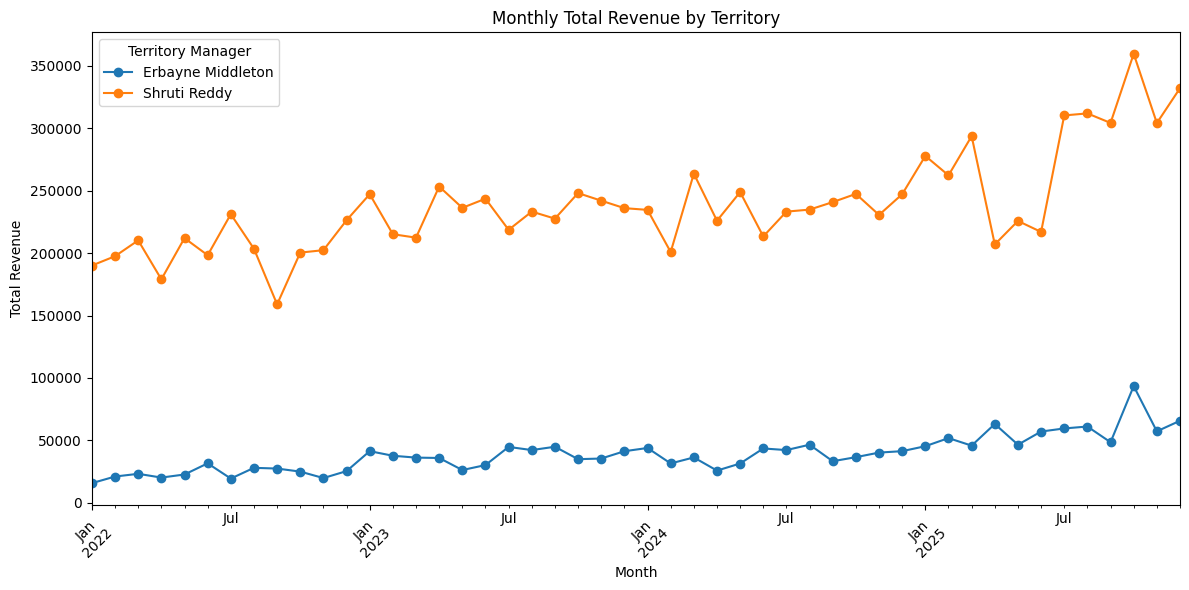

In [17]:
monthly_revenue_pivot = monthly_revenue.pivot(
    index="month",
    columns="Territory Manager",
    values="Sale Amount"
)

monthly_revenue_pivot.plot(figsize=(12, 6), marker="o")
plt.title("Monthly Total Revenue by Territory")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title="Territory Manager")
plt.tight_layout()
plt.show()


This chart makes the revenue gap much easier to read than the table alone. Shruti Reddy’s line stays above Erbayne Middleton’s for nearly the full period, confirming that Maryland is consistently the stronger territory. At the same time, both lines rise over time, which suggests that demand is improving in both territories even though the gap between them remains large.


### Chart 2. Total revenue by category and territory

This bar chart compares total revenue by product category across the two territories. A bar chart works well here because it allows direct category-by-category comparison and quickly highlights where the largest revenue differences appear.


<function matplotlib.pyplot.show(close=None, block=None)>

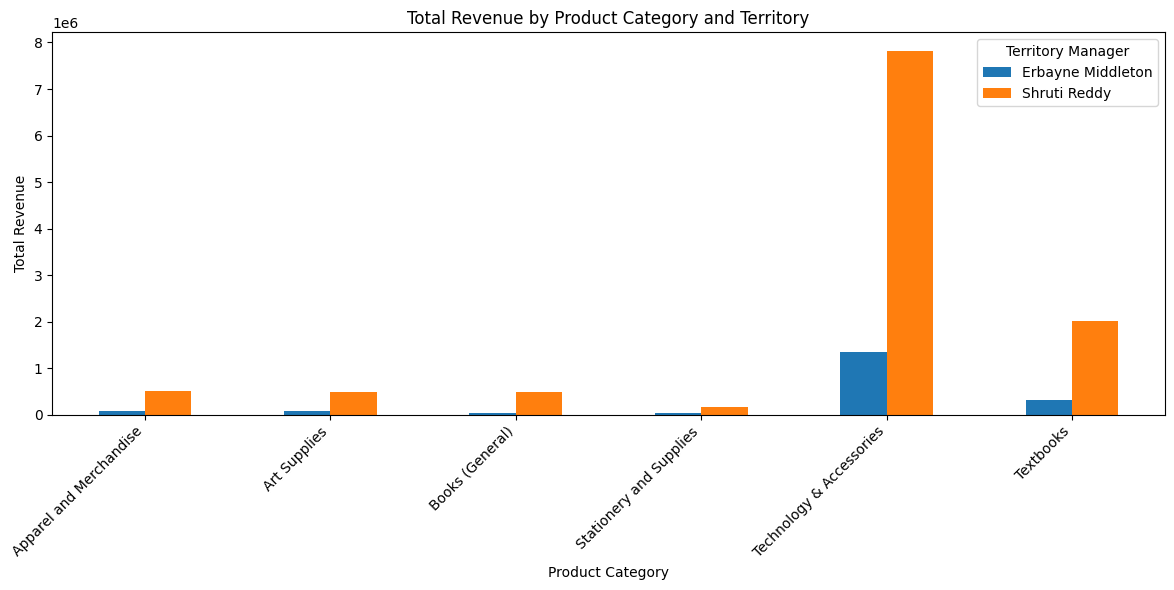

In [18]:
category_pivot = category_summary.pivot(
    index="Category",
    columns="Territory Manager",
    values="total_revenue"
)

category_pivot.plot(kind="bar", figsize=(12,6))
plt.title("Total Revenue by Product Category and Territory")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Territory Manager")
plt.tight_layout()
plt.show

The biggest takeaway from this chart is that the territory gap is concentrated in the categories that matter most. Technology & Accessories dominates both territories, and Textbooks is the next most important category, but Shruti Reddy’s territory leads by a wide margin across every major category. That pattern supports a focused recommendation: if marketing wants the strongest return, it should try to lift Erbayne Middleton’s results in the categories that already generate the most revenue rather than spreading effort evenly across lower-impact categories.
